## **Volleyball Data Analysis**

In [1]:
# Importing required libraries for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the Volleyball dataset into a Pandas DataFrame

df = pd.read_csv("VNL2023.csv")

## **Data Exploration**

In [3]:
# Displaying the first five rows to understand the structure of the dataset

df.head()

,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH


In [4]:
# Checking the number of rows and columns in the dataset

df.shape

(131, 10)

In [5]:
# Generating a statistical summary of the numerical columns

df.describe()

,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,27.809160,5.642672,0.845573,0.535802,2.192595,3.428397,1.684198
std,4.186268,4.256229,0.700896,0.454346,6.031587,2.077823,1.989939
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.530000,0.000000
25%,25.000000,2.800000,0.370000,0.240000,0.000000,1.920000,0.000000
50%,27.000000,5.170000,0.690000,0.420000,0.000000,3.000000,0.330000
75%,30.000000,8.600000,1.140000,0.760000,0.000000,4.510000,3.385000
max,41.000000,15.800000,4.080000,2.080000,26.890000,11.440000,6.690000


In [6]:
# Checking for missing values in each column

df.isna().sum()

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64

In [7]:
# Checking for duplicate records in the dataset

df.duplicated().sum()

np.int64(0)

## **Performance Analysis**

In [8]:
# Selecting numerical columns for correlation analysis
# Calculating the correlation between numerical performance variables

numeric_cols = df.select_dtypes(include = ["int","float"]).columns
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

              Age    Attack     Block     Serve       Set       Dig   Receive
Age      1.000000 -0.177849 -0.101040 -0.108367  0.177757  0.167141 -0.011067
Attack  -0.177849  1.000000  0.338412  0.768859 -0.430805 -0.098999  0.169892
Block   -0.101040  0.338412  1.000000  0.335954 -0.132019 -0.348347 -0.265206
Serve   -0.108367  0.768859  0.335954  1.000000 -0.154815 -0.052501  0.039642
Set      0.177757 -0.430805 -0.132019 -0.154815  1.000000  0.131659 -0.305869
Dig      0.167141 -0.098999 -0.348347 -0.052501  0.131659  1.000000  0.624733
Receive -0.011067  0.169892 -0.265206  0.039642 -0.305869  0.624733  1.000000


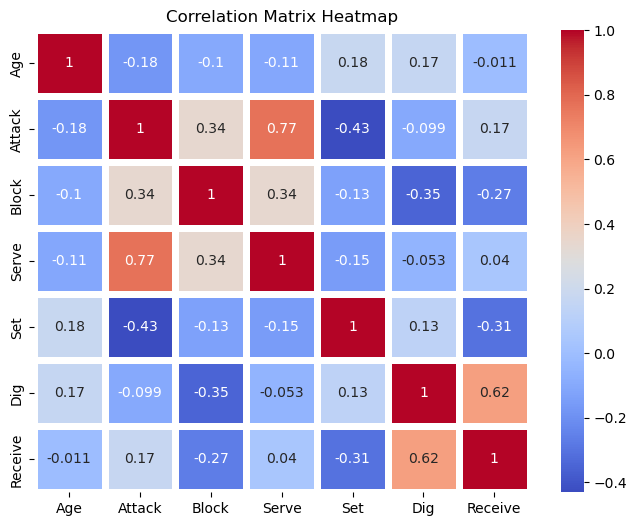

In [9]:
# Visualizing correlations between player performance metrics using a heatmap

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", linewidths = 5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [10]:
# Analyzing the distribution of players across different positions

position_counts = df["Position"].value_counts()
position_counts.index

Index(['OH', 'MB', 'OP', 'S', 'L'], dtype='object', name='Position')

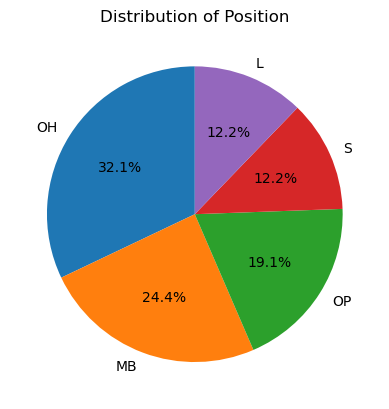

In [11]:
# Visualizing the percentage distribution of players by position

plt.pie(position_counts, labels = position_counts.index, autopct = "%1.1f%%", startangle = 90)
plt.title("Distribution of Position")
plt.show()

In [12]:
# Calculating the average attack performance for each country
# Sorting countries based on average attack performance

avg_attack_by_country = df.groupby("Country")["Attack"].mean()
avg_attack_by_country.sort_values(ascending = False)

Country
France       6.670000
Japan        6.595000
Cuba         6.344286
Serbia       5.998750
Italy        5.965000
Slovenia     5.961250
Argentina    5.925000
Nederland    5.880000
Poland       5.807000
Canada       5.405714
Bulgaria     5.282500
Brazil       5.250000
China        5.093750
Germany      4.833750
Iran         4.707778
USA          4.600000
Name: Attack, dtype: float64

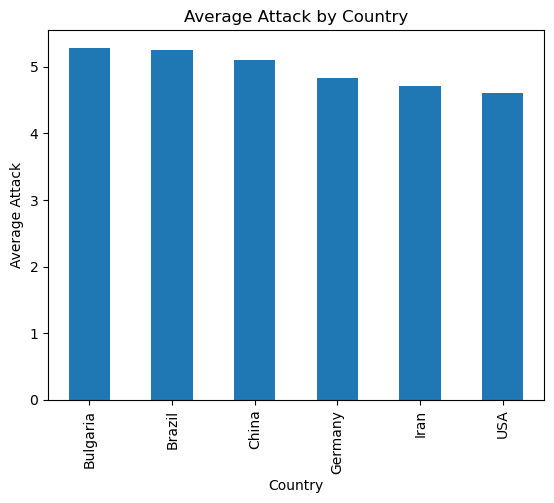

In [13]:
# Visualizing average attack performance by country

avg_attack_by_country.sort_values(ascending = False).tail(6).plot(kind = "bar")
plt.title("Average Attack by Country")
plt.xlabel("Country")
plt.ylabel("Average Attack")
plt.show()

In [14]:
# Calculating the average serve performance for each age group
# Sorting age groups based on average serve performance

avg_serve_by_age = df.groupby("Age")["Serve"].mean()
avg_serve_by_age.sort_values(ascending = False)

Age
31    0.910000
20    0.880000
21    0.770000
26    0.681053
28    0.667273
35    0.666667
27    0.662500
36    0.660000
24    0.640667
22    0.534286
23    0.526667
29    0.477500
30    0.429231
38    0.400000
33    0.321429
32    0.290000
37    0.270000
19    0.200000
25    0.165714
34    0.026667
41    0.000000
Name: Serve, dtype: float64

In [15]:
# Finding the maximum attack value for each country and player position

df.groupby(["Country", "Position"])["Attack"].max().reset_index().sort_values(ascending = False, by = "Attack").tail(20)

,Country,Position,Attack
19,Canada,S,0.17
54,Japan,S,0.13
39,Germany,S,0.08
60,Poland,L,0.00
30,France,L,0.00
5,Brazil,L,0.00
10,Bulgaria,L,0.00
15,Canada,L,0.00
74,USA,L,0.00
20,China,L,0.00


In [16]:
# Calculating the total Dig performance for each country

df.groupby("Country")["Dig"].sum()

Country
Argentina    33.88
Brazil       24.61
Bulgaria     22.45
Canada       26.50
China        22.08
Cuba         20.26
France       38.59
Germany      20.92
Iran         24.25
Italy        35.89
Japan        32.38
Nederland    21.84
Poland       32.56
Serbia       30.64
Slovenia     33.85
USA          28.42
Name: Dig, dtype: float64

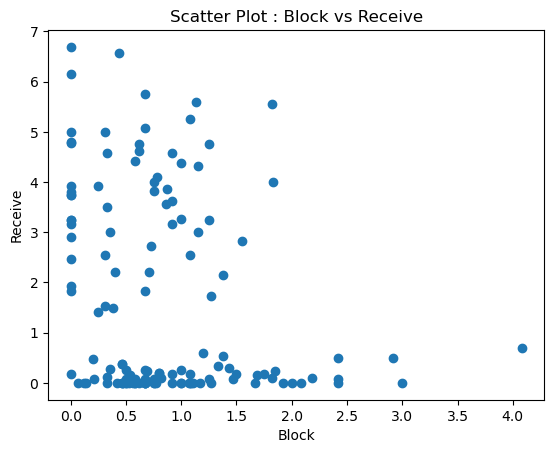

In [17]:
# Analyzing the relationship between Block and Receive performance

plt.scatter(df["Block"], df["Receive"])
plt.title("Scatter Plot : Block vs Receive")
plt.xlabel("Block")
plt.ylabel("Receive")
plt.show()

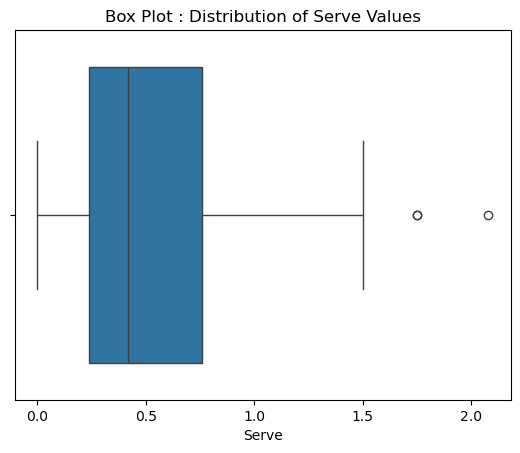

In [18]:
# Visualizing the distribution of Serve performance using a box plot

sns.boxplot(x = df["Serve"])
plt.title("Box Plot : Distribution of Serve Values")
plt.xlabel("Serve")
plt.show()

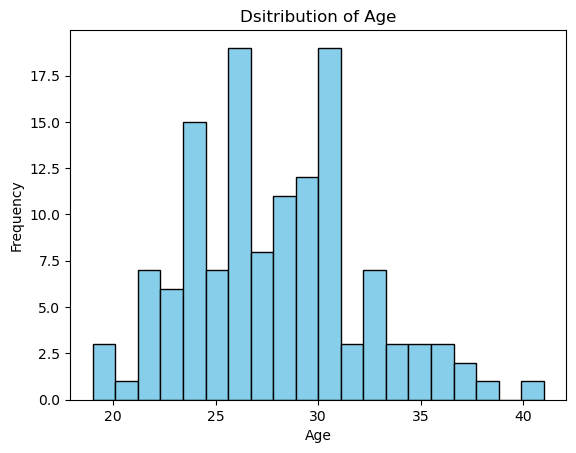

In [19]:
# Analyzing the age distribution of the players

plt.hist(df["Age"], bins = 20, color = "skyblue", edgecolor = "black")
plt.title("Dsitribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

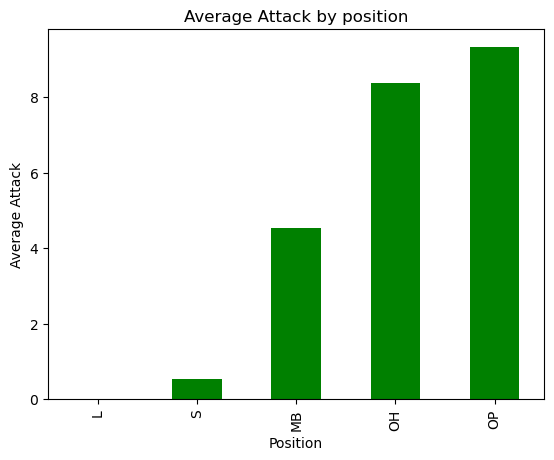

In [20]:
# Calculating the average attack performance for each player position
# Sorting positions and visualizing their average attack performance

avg_attack_by_position = df.groupby("Position")["Attack"].mean()

avg_attack_by_position.sort_values(ascending = True).plot(kind = "bar", color = "green")
plt.title("Average Attack by position")
plt.xlabel("Position")
plt.ylabel("Average Attack")
plt.show()

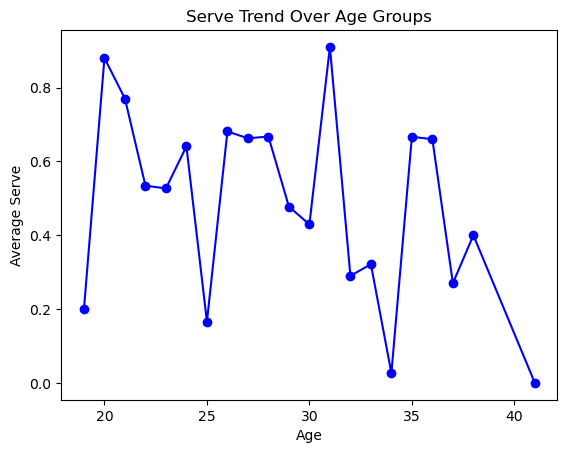

In [21]:
# Analyzing how average serve performance changes across different age groups

serve_trend_by_age = df.groupby("Age")["Serve"].mean()

serve_trend_by_age.plot(kind = "line", marker = "o", linestyle = "-", color = "blue")
plt.title("Serve Trend Over Age Groups")
plt.xlabel("Age")
plt.ylabel("Average Serve")
plt.show()

In [22]:
# Calculating the total Attack and Block performance for each country

total_attack_block_by_country = df.groupby("Country")[["Attack", "Block"]].sum()

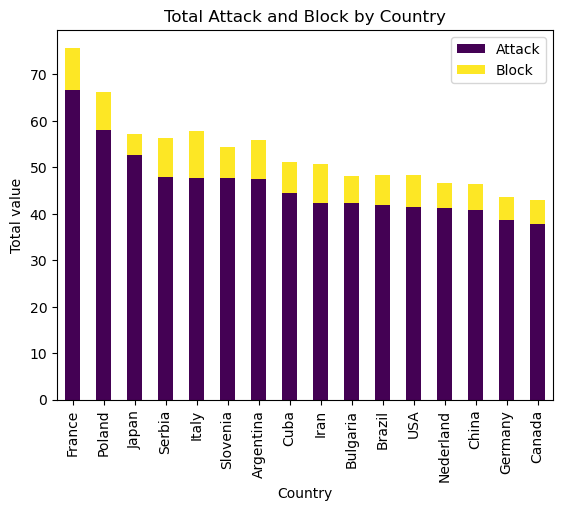

In [23]:
# Sorting countries based on total Attack performance

total_attack_block_by_country.sort_values(ascending = False, by = "Attack").plot(kind = "bar", stacked = True, colormap = "viridis")
plt.title("Total Attack and Block by Country")
plt.xlabel("Country")
plt.ylabel("Total value")
plt.show()

## **Conclusion**

France and Japan showed higher average attack performance, while OH and OP positions showed higher average attack.
A strong relationship was observed between Attack and Serve, and between Dig and Receive, highlighting important player performance patterns

**Complete Project on GitHub :** https://github.com/DIVYAGHODE/Python-Volleyball-Data-Analysis-Project